In [3]:
import os
print(os.listdir('checkpoints'))

['loss_history.csv', 'loss_history.json', 'loss_plot.png', 'restormer_best_model.pth', 'restormer_last_checkpoint.pth', 'scunet_last_checkpoint.pth', 'unet_best_model.pth', 'unet_last_checkpoint.pth']


# Ю-нет перавый

Используется устройство: cpu
📁 Загружено пар снимков: 10
🎉 Сформирован индекс: 640 патчей 512x512
✅ Успешно загружены веса лучшей модели из: 'checkpoints/unet_best_model.pth'


/tmp/ipykernel_3303/414885162.py:301: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/kernel/lib/python3.10/site-packages/ml_kernel/_vendor/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/kernel/lib/python3.10/site-packages/ml_kernel/_vendor/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


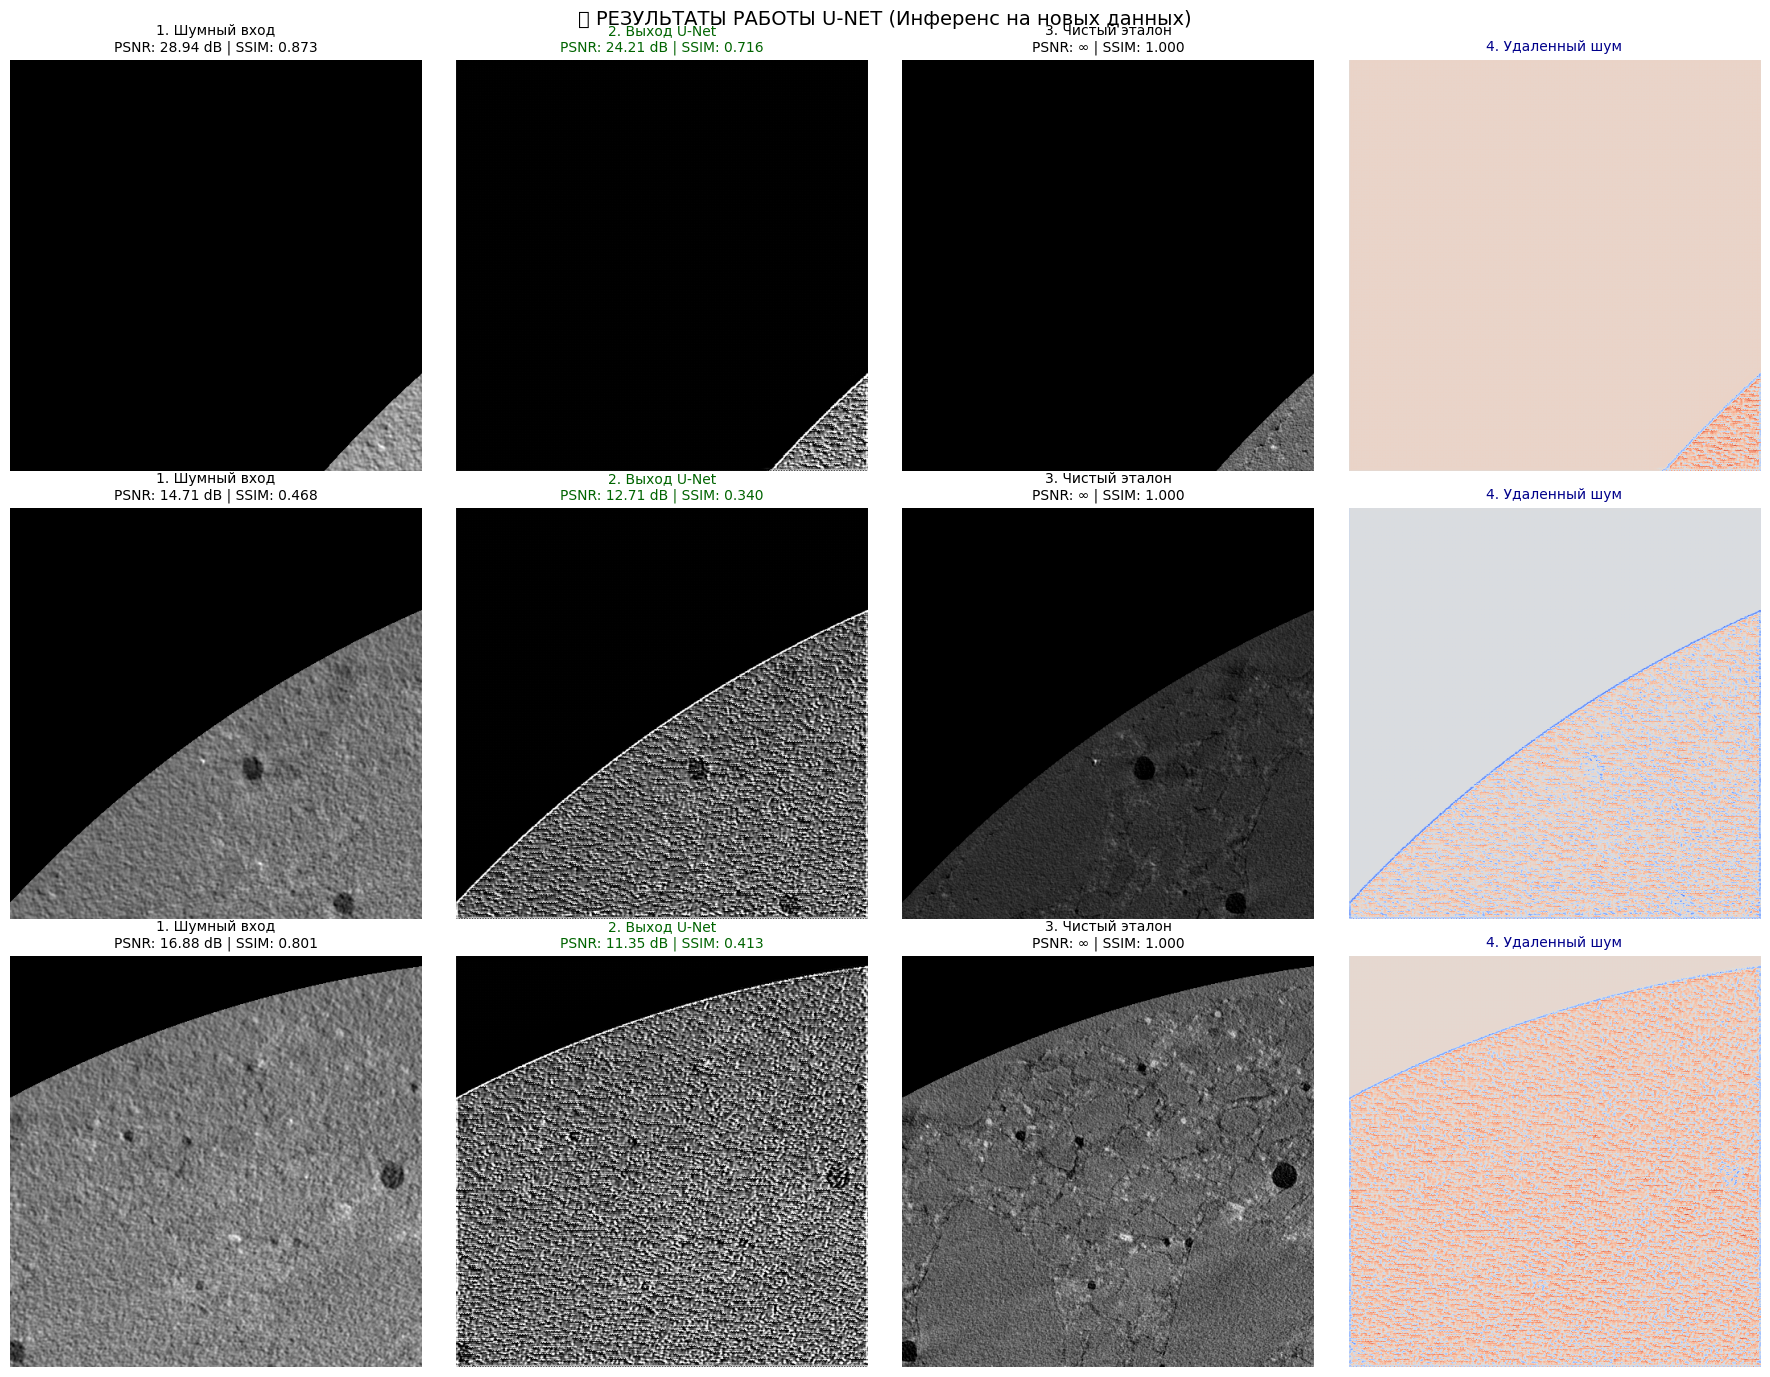

📈 ИТОГОВЫЙ ПРИРОСТ КАЧЕСТВА (Среднее по 3 образцам):
• Метрика PSNR:  было 20.17 dB ──► стало 16.09 dB (Прирост: +-4.09 dB 🚀)
• Метрика SSIM:  было 0.714    ──► стало 0.490    (Прирост: +-0.224 🚀)


In [4]:
# =============================================================================
# 1. ИМПОРТЫ
# =============================================================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tifffile as tiff

# =============================================================================
# 2. ОПРЕДЕЛЕНИЕ ФУНКЦИЙ И КЛАССОВ (копия из первого ноутбука)
# =============================================================================

# --- 2.1. Функция нарезки патчей ---
def slice_image_to_patches(image_or_path, patch_size=512, overlap_ratio=0.2):
    if isinstance(image_or_path, str):
        img = tiff.imread(image_or_path).astype(np.float32)
    else:
        img = image_or_path.astype(np.float32)
    h, w = img.shape
    stride = int(patch_size * (1.0 - overlap_ratio))
    y_steps = list(range(0, h - patch_size + 1, stride))
    if y_steps[-1] != h - patch_size:
        y_steps.append(h - patch_size)
    x_steps = list(range(0, w - patch_size + 1, stride))
    if x_steps[-1] != w - patch_size:
        x_steps.append(w - patch_size)
    patches = []
    coords = []
    for y in y_steps:
        for x in x_steps:
            patches.append(img[y:y+patch_size, x:x+patch_size])
            coords.append((y, x))
    return np.array(patches), coords, (h, w)

# --- 2.2. Аугментация D4 + Crop (используется при обучении, но для инференса она не нужна) ---
# Мы её копируем, но в датасете для инференса передадим transform_fn=None
def d4_crop_ct_augmentation(noisy_tensor, clean_tensor, crop_size=256):
    import torchvision.transforms.functional as TF
    import random
    _, h, w = noisy_tensor.shape
    if h > crop_size and w > crop_size:
        top = random.randint(0, h - crop_size)
        left = random.randint(0, w - crop_size)
        noisy_tensor = noisy_tensor[:, top:top+crop_size, left:left+crop_size]
        clean_tensor = clean_tensor[:, top:top+crop_size, left:left+crop_size]
    if random.random() > 0.5:
        noisy_tensor = TF.hflip(noisy_tensor)
        clean_tensor = TF.hflip(clean_tensor)
    if random.random() > 0.5:
        noisy_tensor = TF.vflip(noisy_tensor)
        clean_tensor = TF.vflip(clean_tensor)
    k = random.randint(0, 3)
    if k > 0:
        noisy_tensor = torch.rot90(noisy_tensor, k, dims=[1, 2])
        clean_tensor = torch.rot90(clean_tensor, k, dims=[1, 2])
    return noisy_tensor, clean_tensor

# --- 2.3. Датасет CTModularDataset (без кэша для простоты) ---
class CTModularDataset(Dataset):
    def __init__(
        self, 
        noisy_dir, 
        clean_dir, 
        patch_size=512, 
        overlap_ratio=0.2, 
        num_images=None,
        transform_fn=None
    ):
        self.patch_size = patch_size
        self.transform_fn = transform_fn
        
        noisy_files = sorted([f for f in os.listdir(noisy_dir) if f.lower().endswith(('.tif', '.tiff'))])
        clean_files = sorted([f for f in os.listdir(clean_dir) if f.lower().endswith(('.tif', '.tiff'))])
        common = sorted(list(set(noisy_files) & set(clean_files)))
        
        if num_images is not None:
            self.common_names = common[:num_images]
        else:
            self.common_names = common

        self.noisy_paths = [os.path.join(noisy_dir, f) for f in self.common_names]
        self.clean_paths = [os.path.join(clean_dir, f) for f in self.common_names]

        _, self.base_coords, _ = slice_image_to_patches(self.noisy_paths[0], patch_size, overlap_ratio)

        self.patch_index = []
        for img_idx in range(len(self.common_names)):
            for y, x in self.base_coords:
                self.patch_index.append((img_idx, y, x))

        print(f"📁 Загружено пар снимков: {len(self.common_names)}")
        print(f"🎉 Сформирован индекс: {len(self.patch_index)} патчей {patch_size}x{patch_size}")

    def __len__(self):
        return len(self.patch_index)

    def __getitem__(self, idx):
        img_idx, y, x = self.patch_index[idx]
        p = self.patch_size

        n_img = tiff.imread(self.noisy_paths[img_idx]).astype(np.float32)
        c_img = tiff.imread(self.clean_paths[img_idx]).astype(np.float32)

        n_patch = n_img[y:y+p, x:x+p]
        c_patch = c_img[y:y+p, x:x+p]

        n_patch = (n_patch - np.min(n_patch)) / (np.max(n_patch) - np.min(n_patch) + 1e-8)
        c_patch = (c_patch - np.min(c_patch)) / (np.max(c_patch) - np.min(c_patch) + 1e-8)

        n_tensor = torch.from_numpy(n_patch).unsqueeze(0).float()
        c_tensor = torch.from_numpy(c_patch).unsqueeze(0).float()

        if self.transform_fn is not None:
            n_tensor, c_tensor = self.transform_fn(n_tensor, c_tensor)

        return n_tensor, c_tensor

# =============================================================================
# 3. ОПРЕДЕЛЕНИЕ МОДЕЛИ U-Net (должна совпадать с обученной)
# =============================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNetDenoising(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature))
            current_in = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        original_input = x
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip_conn = skip_connections[i // 2]
            x = self.ups[i + 1](torch.cat((skip_conn, x), dim=1))

        predicted_noise = self.final_conv(x)
        cleaned_patch = original_input - predicted_noise
        return cleaned_patch

# =============================================================================
# 4. ЗАГРУЗКА МОДЕЛИ И ДАННЫХ
# =============================================================================

# --- 4.1. Выбор устройства ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# --- 4.2. Пути к данным (должны совпадать с первым ноутбуком) ---
NOISY_DIR = "filestore/filestorage/V_beton30_angle05"
CLEAN_DIR = "filestore/filestorage/V_beton30_angle005"

# --- 4.3. Создаём датасет для инференса (небольшой, только для демонстрации) ---
all_files = sorted(list(set(os.listdir(NOISY_DIR)) & set(os.listdir(CLEAN_DIR))))
num_demo = 10  # сколько файлов взять для демонстрации
demo_dataset = CTModularDataset(
    noisy_dir=NOISY_DIR,
    clean_dir=CLEAN_DIR,
    patch_size=512,
    overlap_ratio=0.2,
    num_images=num_demo,
    transform_fn=None
)

# --- 4.4. Загрузка обученной модели ---
BEST_MODEL_PATH = "checkpoints/unet_best_model.pth"
model = UNetDenoising(in_channels=1, out_channels=1).to(device)

if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    print(f"✅ Успешно загружены веса лучшей модели из: '{BEST_MODEL_PATH}'")
else:
    print("⚠️ Файл чекпоинта не найден! Проверьте путь.")

model.eval()

# =============================================================================
# 5. ФУНКЦИИ ДЛЯ РАСЧЁТА МЕТРИК (PSNR, SSIM)
# =============================================================================
def calculate_psnr(pred, target):
    mse = np.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))

def calculate_ssim(img1, img2):
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    mu1 = img1.mean()
    mu2 = img2.mean()
    sigma1 = np.var(img1)
    sigma2 = np.var(img2)
    sigma12 = np.mean((img1 - mu1) * (img2 - mu2))
    ssim = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) * (sigma1 + sigma2 + C2))
    return ssim

# =============================================================================
# 6. ВЫБОР ИНФОРМАТИВНЫХ ПАТЧЕЙ И ВИЗУАЛИЗАЦИЯ
# =============================================================================

# --- 6.1. Выбираем 3 случайных индекса (или ищем с высоким std) ---
selected_indices = []
# Попробуем найти патчи с высокой дисперсией (структура)
for idx in range(len(demo_dataset)):
    # Берём чистый патч (индекс патча, но нам нужен сам патч)
    img_idx, y, x = demo_dataset.patch_index[idx]
    clean_patch = tiff.imread(demo_dataset.clean_paths[img_idx])[y:y+512, x:x+512].astype(np.float32)
    if np.std(clean_patch) > 0.04:
        selected_indices.append(idx)
        if len(selected_indices) == 3:
            break

if len(selected_indices) < 3:
    # Если не нашли, берём первые, серединный и последний
    selected_indices = [0, len(demo_dataset)//2, len(demo_dataset)-1]

# --- 6.2. Прогон через модель и отрисовка ---
fig, axes = plt.subplots(3, 4, figsize=(18, 14))

psnr_noisy_list, psnr_pred_list = [], []
ssim_noisy_list, ssim_pred_list = [], []

for row, idx in enumerate(selected_indices):
    noisy_tensor, clean_tensor = demo_dataset[idx]
    
    with torch.no_grad():
        input_b = noisy_tensor.unsqueeze(0).to(device)
        pred_tensor = model(input_b)
    
    noisy_np = noisy_tensor.squeeze().cpu().numpy()
    pred_np = pred_tensor.squeeze().cpu().numpy()
    clean_np = clean_tensor.squeeze().cpu().numpy()
    
    pred_np = np.clip(pred_np, 0.0, 1.0)
    noise_extracted = noisy_np - pred_np
    
    psnr_noisy = calculate_psnr(noisy_np, clean_np)
    psnr_pred = calculate_psnr(pred_np, clean_np)
    ssim_noisy = calculate_ssim(noisy_np, clean_np)
    ssim_pred = calculate_ssim(pred_np, clean_np)
    
    psnr_noisy_list.append(psnr_noisy)
    psnr_pred_list.append(psnr_pred)
    ssim_noisy_list.append(ssim_noisy)
    ssim_pred_list.append(ssim_pred)
    
    axes[row, 0].imshow(noisy_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f"1. Шумный вход\nPSNR: {psnr_noisy:.2f} dB | SSIM: {ssim_noisy:.3f}", fontsize=10)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(pred_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f"2. Выход U-Net\nPSNR: {psnr_pred:.2f} dB | SSIM: {ssim_pred:.3f}", fontsize=10, color='darkgreen')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(clean_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_title(f"3. Чистый эталон\nPSNR: ∞ | SSIM: 1.000", fontsize=10)
    axes[row, 2].axis('off')
    
    axes[row, 3].imshow(noise_extracted, cmap='coolwarm')
    axes[row, 3].set_title("4. Удаленный шум", fontsize=10, color='darkblue')
    axes[row, 3].axis('off')

plt.suptitle("📊 РЕЗУЛЬТАТЫ РАБОТЫ U-NET (Инференс на новых данных)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# --- 6.3. Итоговый отчёт ---
print("=" * 65)
print("📈 ИТОГОВЫЙ ПРИРОСТ КАЧЕСТВА (Среднее по 3 образцам):")
print(f"• Метрика PSNR:  было {np.mean(psnr_noisy_list):.2f} dB ──► стало {np.mean(psnr_pred_list):.2f} dB (Прирост: +{np.mean(psnr_pred_list) - np.mean(psnr_noisy_list):.2f} dB 🚀)")
print(f"• Метрика SSIM:  было {np.mean(ssim_noisy_list):.3f}    ──► стало {np.mean(ssim_pred_list):.3f}    (Прирост: +{np.mean(ssim_pred_list) - np.mean(ssim_noisy_list):.3f} 🚀)")
print("=" * 65)

# СКАМнет Нублин

Используется устройство: cpu


/home/jupyter/.local/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


📁 Загружено пар снимков: 10
🎉 Сформирован индекс: 640 патчей 512x512
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_

/tmp/ipykernel_3303/1827002843.py:141: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/kernel/lib/python3.10/site-packages/ml_kernel/_vendor/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/kernel/lib/python3.10/site-packages/ml_kernel/_vendor/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


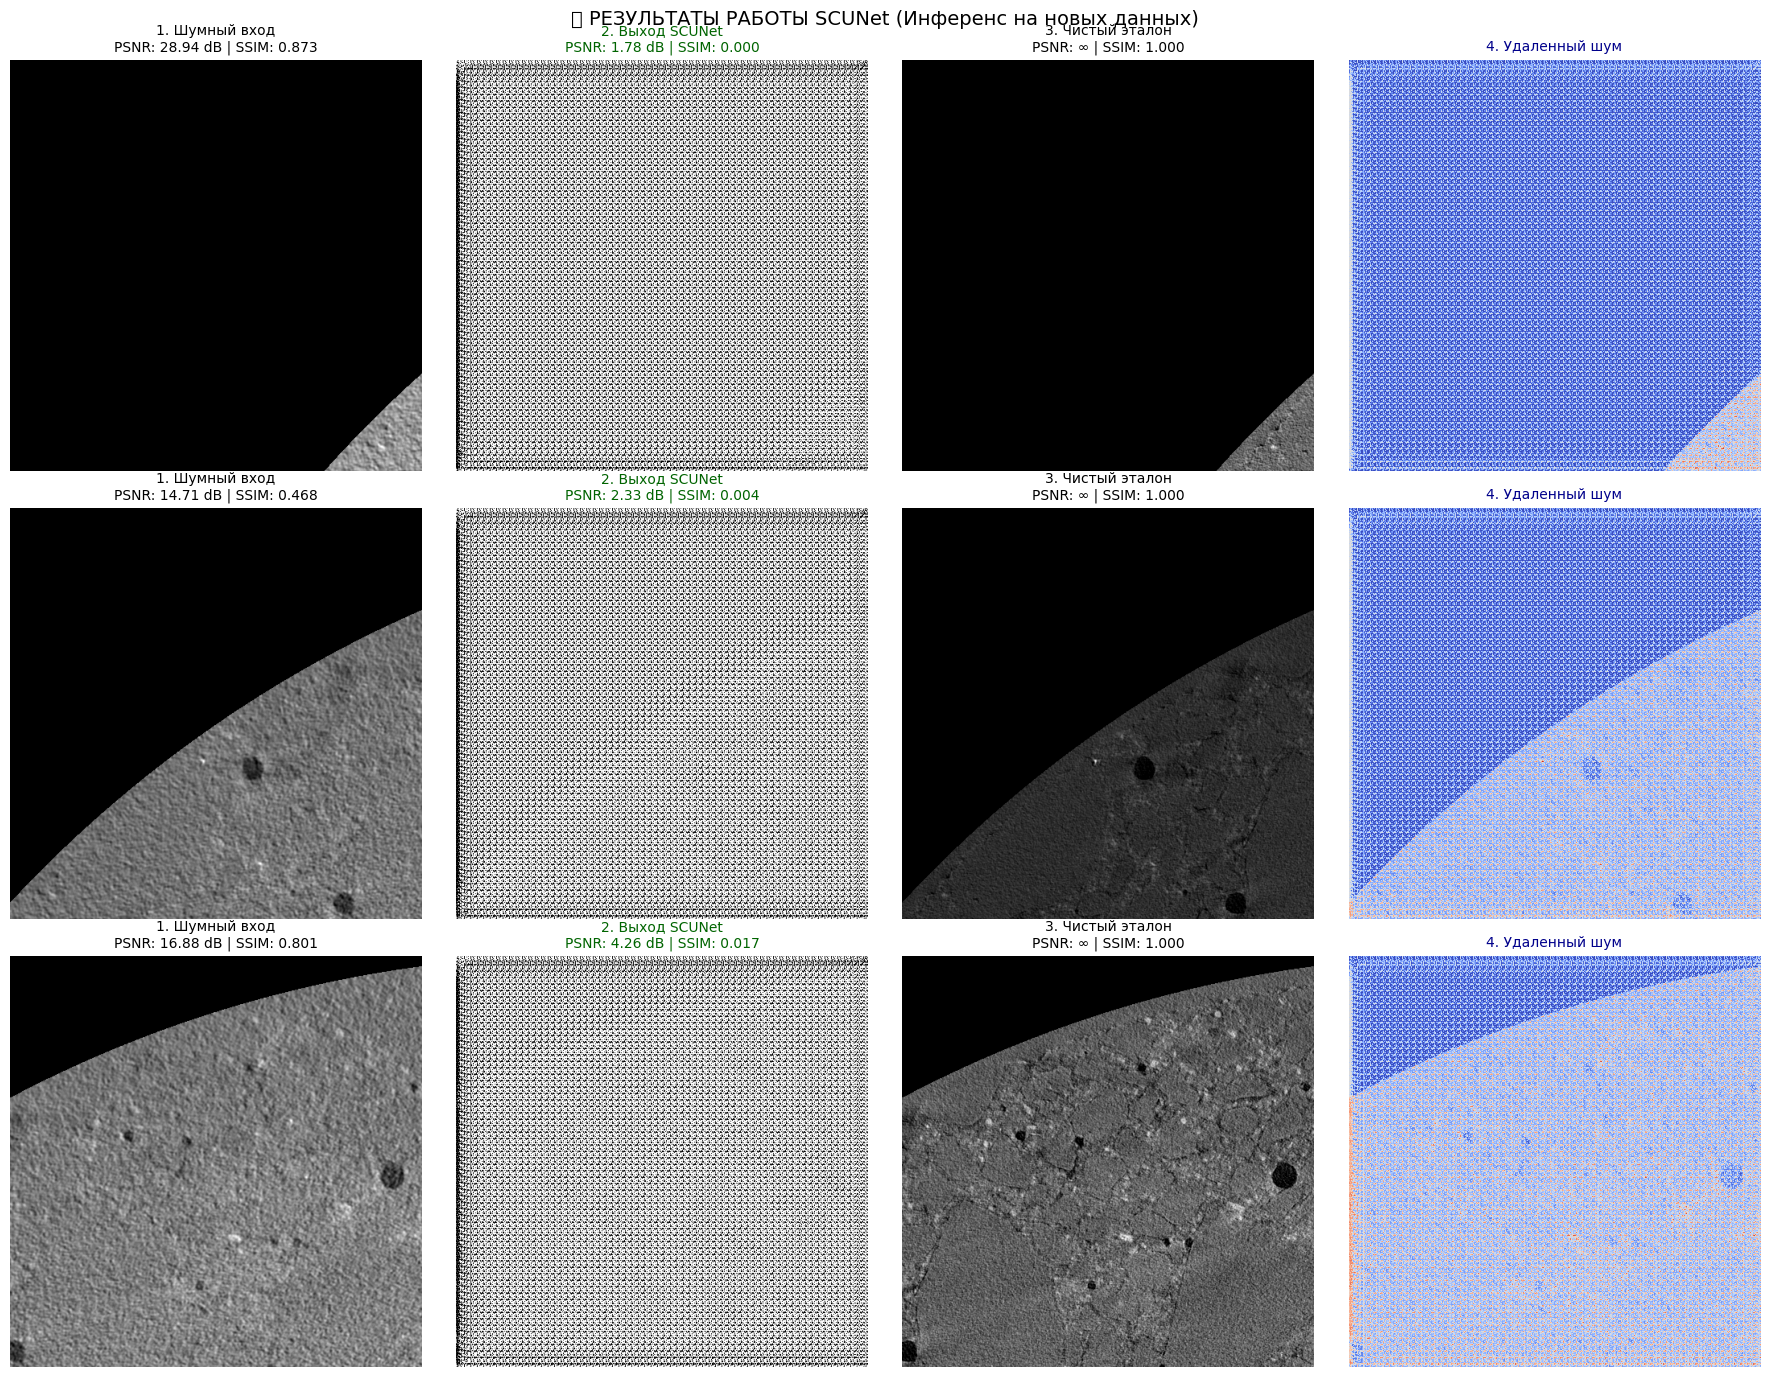

📈 ИТОГОВЫЙ ПРИРОСТ КАЧЕСТВА (Среднее по 3 образцам):
• Метрика PSNR:  было 20.17 dB ──► стало 2.79 dB (Прирост: +-17.39 dB 🚀)
• Метрика SSIM:  было 0.714    ──► стало 0.007    (Прирост: +-0.707 🚀)


In [5]:
# =============================================================================
# 4. ЗАГРУЗКА SCUNet И ДАННЫХ
# =============================================================================

import sys
from pathlib import Path

# --- 4.1. Путь к SCUNet (если ещё не добавлен) ---
SCUNET_DIR = Path("SCUNet")
if not SCUNET_DIR.exists():
    raise FileNotFoundError("Папка SCUNet не найдена. Убедитесь, что вы клонировали репозиторий.")
if str(SCUNET_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SCUNET_DIR.resolve()))

# --- 4.2. Импорт модели SCUNet ---
from models.network_scunet import SCUNet

# --- 4.3. Выбор устройства ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# --- 4.4. Пути к данным (должны совпадать с обучением) ---
NOISY_DIR = "filestore/filestorage/V_beton30_angle05"
CLEAN_DIR = "filestore/filestorage/V_beton30_angle005"

# --- 4.5. Создаём датасет для инференса (небольшой, только для демонстрации) ---
all_files = sorted(list(set(os.listdir(NOISY_DIR)) & set(os.listdir(CLEAN_DIR))))
num_demo = 10  # сколько файлов взять для демонстрации
demo_dataset = CTModularDataset(
    noisy_dir=NOISY_DIR,
    clean_dir=CLEAN_DIR,
    patch_size=512,
    overlap_ratio=0.2,
    num_images=num_demo,
    transform_fn=None
)

# --- 4.6. Инициализация SCUNet (параметры как при обучении) ---
model = SCUNet(in_nc=1, config=[4, 4, 4, 4, 4, 4, 4], dim=64).to(device)

# --- 4.7. Загрузка обученных весов из последнего чекпоинта ---
CHECKPOINT_PATH = "checkpoints/scunet_last_checkpoint.pth"
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    # Если чекпоинт содержит полное состояние (с эпохой и т.д.)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Загружены веса из '{CHECKPOINT_PATH}' (эпоха {checkpoint.get('epoch', '?')})")
    else:
        model.load_state_dict(checkpoint)
        print(f"✅ Загружены веса из '{CHECKPOINT_PATH}' (только state_dict)")
else:
    print(f"⚠️ Чекпоинт не найден: {CHECKPOINT_PATH}. Используется случайная инициализация.")

model.eval()

# =============================================================================
# 5. ФУНКЦИИ ДЛЯ РАСЧЁТА МЕТРИК (PSNR, SSIM)
# =============================================================================
def calculate_psnr(pred, target):
    mse = np.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))

def calculate_ssim(img1, img2):
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    mu1 = img1.mean()
    mu2 = img2.mean()
    sigma1 = np.var(img1)
    sigma2 = np.var(img2)
    sigma12 = np.mean((img1 - mu1) * (img2 - mu2))
    ssim = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) * (sigma1 + sigma2 + C2))
    return ssim

# =============================================================================
# 6. ВЫБОР ИНФОРМАТИВНЫХ ПАТЧЕЙ И ВИЗУАЛИЗАЦИЯ
# =============================================================================

# --- 6.1. Выбираем 3 случайных индекса (или ищем с высоким std) ---
selected_indices = []
for idx in range(len(demo_dataset)):
    img_idx, y, x = demo_dataset.patch_index[idx]
    clean_patch = tiff.imread(demo_dataset.clean_paths[img_idx])[y:y+512, x:x+512].astype(np.float32)
    if np.std(clean_patch) > 0.04:
        selected_indices.append(idx)
        if len(selected_indices) == 3:
            break

if len(selected_indices) < 3:
    selected_indices = [0, len(demo_dataset)//2, len(demo_dataset)-1]

# --- 6.2. Прогон через модель и отрисовка ---
fig, axes = plt.subplots(3, 4, figsize=(18, 14))

psnr_noisy_list, psnr_pred_list = [], []
ssim_noisy_list, ssim_pred_list = [], []

for row, idx in enumerate(selected_indices):
    noisy_tensor, clean_tensor = demo_dataset[idx]
    
    with torch.no_grad():
        input_b = noisy_tensor.unsqueeze(0).to(device)
        pred_tensor = model(input_b)
    
    noisy_np = noisy_tensor.squeeze().cpu().numpy()
    pred_np = pred_tensor.squeeze().cpu().numpy()
    clean_np = clean_tensor.squeeze().cpu().numpy()
    
    pred_np = np.clip(pred_np, 0.0, 1.0)
    noise_extracted = noisy_np - pred_np
    
    psnr_noisy = calculate_psnr(noisy_np, clean_np)
    psnr_pred = calculate_psnr(pred_np, clean_np)
    ssim_noisy = calculate_ssim(noisy_np, clean_np)
    ssim_pred = calculate_ssim(pred_np, clean_np)
    
    psnr_noisy_list.append(psnr_noisy)
    psnr_pred_list.append(psnr_pred)
    ssim_noisy_list.append(ssim_noisy)
    ssim_pred_list.append(ssim_pred)
    
    axes[row, 0].imshow(noisy_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f"1. Шумный вход\nPSNR: {psnr_noisy:.2f} dB | SSIM: {ssim_noisy:.3f}", fontsize=10)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(pred_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f"2. Выход SCUNet\nPSNR: {psnr_pred:.2f} dB | SSIM: {ssim_pred:.3f}", fontsize=10, color='darkgreen')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(clean_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_title(f"3. Чистый эталон\nPSNR: ∞ | SSIM: 1.000", fontsize=10)
    axes[row, 2].axis('off')
    
    axes[row, 3].imshow(noise_extracted, cmap='coolwarm')
    axes[row, 3].set_title("4. Удаленный шум", fontsize=10, color='darkblue')
    axes[row, 3].axis('off')

plt.suptitle("📊 РЕЗУЛЬТАТЫ РАБОТЫ SCUNet (Инференс на новых данных)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# --- 6.3. Итоговый отчёт ---
print("=" * 65)
print("📈 ИТОГОВЫЙ ПРИРОСТ КАЧЕСТВА (Среднее по 3 образцам):")
print(f"• Метрика PSNR:  было {np.mean(psnr_noisy_list):.2f} dB ──► стало {np.mean(psnr_pred_list):.2f} dB (Прирост: +{np.mean(psnr_pred_list) - np.mean(psnr_noisy_list):.2f} dB 🚀)")
print(f"• Метрика SSIM:  было {np.mean(ssim_noisy_list):.3f}    ──► стало {np.mean(ssim_pred_list):.3f}    (Прирост: +{np.mean(ssim_pred_list) - np.mean(ssim_noisy_list):.3f} 🚀)")
print("=" * 65)

# Нормальный скамнет а не херня

In [5]:
import os
import re
import numpy as np
import tifffile as tiff
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Функция извлечения номера файла
def get_file_number(filename):
    """Извлекает числовой номер из имени файла (например, 'rec_00440.tif' -> 440)"""
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1


class CTModularDataset(Dataset):
    def __init__(
        self, 
        noisy_dir, 
        clean_dir, 
        file_list=None,        # 🔥 ПЕРЕДАЕМ ГОТОВЫЙ СПИСОК (train_files или val_files)
        patch_size=512, 
        overlap_ratio=0.2, 
        transform_fn=None
    ):
        self.patch_size = patch_size
        self.transform_fn = transform_fn
        
        # Если список файлов передан напрямую (train или val) — берем его
        if file_list is not None:
            self.common_names = file_list
        else:
            noisy_files = sorted([f for f in os.listdir(noisy_dir) if f.lower().endswith(('.tif', '.tiff'))])
            clean_files = sorted([f for f in os.listdir(clean_dir) if f.lower().endswith(('.tif', '.tiff'))])
            self.common_names = sorted(list(set(noisy_files) & set(clean_files)))

        self.noisy_paths = [os.path.join(noisy_dir, f) for f in self.common_names]
        self.clean_paths = [os.path.join(clean_dir, f) for f in self.common_names]

        # 2. Построение координатной сетки
        _, self.base_coords, _ = slice_image_to_patches(self.noisy_paths[0], patch_size, overlap_ratio)

        # 3. Строим точный индекс только для переданных файлов
        self.patch_index = [
            (img_idx, y, x) 
            for img_idx in range(len(self.common_names)) 
            for y, x in self.base_coords
        ]

        print(f"📁 Загружено пар снимков: {len(self.common_names)} (от {self.common_names[0]} до {self.common_names[-1]})")
        print(f"🎉 Сформирован индекс: {len(self.patch_index)} патчей {patch_size}x{patch_size}")
        print(f"🔄 Стратегия аугментации: {transform_fn.__name__ if transform_fn else 'Без аугментации'}\n")

    def __len__(self):
        return len(self.patch_index)

    def __getitem__(self, idx):
        img_idx, y, x = self.patch_index[idx]
        p = self.patch_size

        n_img = tiff.imread(self.noisy_paths[img_idx]).astype(np.float32)
        c_img = tiff.imread(self.clean_paths[img_idx]).astype(np.float32)

        n_patch = n_img[y:y+p, x:x+p]
        c_patch = c_img[y:y+p, x:x+p]

        # Нормализация [0, 1]
        n_patch = (n_patch - np.min(n_patch)) / (np.max(n_patch) - np.min(n_patch) + 1e-8)
        c_patch = (c_patch - np.min(c_patch)) / (np.max(c_patch) - np.min(c_patch) + 1e-8)

        n_tensor = torch.from_numpy(n_patch).unsqueeze(0).float()
        c_tensor = torch.from_numpy(c_patch).unsqueeze(0).float()

        if self.transform_fn is not None:
            n_tensor, c_tensor = self.transform_fn(n_tensor, c_tensor)

        return n_tensor, c_tensor

    def _load_and_cache_file(self, img_idx):
        """Загружает весь файл, нарезает все патчи и сохраняет в self._cache"""
        noisy_path = self.noisy_paths[img_idx]
        clean_path = self.clean_paths[img_idx]

        n_img = tiff.imread(noisy_path).astype(np.float32)
        c_img = tiff.imread(clean_path).astype(np.float32)

        p = self.patch_size
        cache = {}
        for y, x in self.base_coords:
            n_patch = n_img[y:y+p, x:x+p]
            c_patch = c_img[y:y+p, x:x+p]
            cache[(y, x)] = (n_patch, c_patch)

        self._cache = cache

In [6]:
# =============================================================================
# ТЕСТИРОВАНИЕ (INFERENCE) SCUNet — с проверкой TIFF
# =============================================================================

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import tifffile as tiff
from pathlib import Path

# --- 1. Путь к SCUNet ---
SCUNET_DIR = Path("SCUNet")
if not SCUNET_DIR.exists():
    raise FileNotFoundError("Папка SCUNet не найдена. Убедитесь, что вы клонировали репозиторий.")
if str(SCUNET_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SCUNET_DIR.resolve()))

from models.network_scunet import SCUNet

# --- 2. Устройство ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# --- 3. Пути к данным ---
NOISY_DIR = "filestore/filestorage/V_beton30_angle05"
CLEAN_DIR = "filestore/filestorage/V_beton30_angle005"

# --- 4. Функция проверки валидности TIFF ---
def is_valid_tiff(filepath):
    try:
        with tiff.TiffFile(filepath) as tif:
            return True
    except Exception:
        return False

# --- 5. Формируем список валидных пар ---
all_files = sorted(list(set(os.listdir(NOISY_DIR)) & set(os.listdir(CLEAN_DIR))))
print(f"Всего файлов по расширению: {len(all_files)}")

valid_files = []
for f in all_files:
    noisy_path = os.path.join(NOISY_DIR, f)
    clean_path = os.path.join(CLEAN_DIR, f)
    if is_valid_tiff(noisy_path) and is_valid_tiff(clean_path):
        valid_files.append(f)

print(f"Из них валидных пар: {len(valid_files)}")

num_demo = 10  # сколько файлов взять для демонстрации
demo_files = valid_files[:num_demo]

if len(demo_files) == 0:
    raise ValueError("Нет валидных TIFF файлов в указанных директориях.")

print(f"Взято {len(demo_files)} файлов для демонстрации")

# --- 6. Создаём датасет (используем file_list) ---
demo_dataset = CTModularDataset(
    noisy_dir=NOISY_DIR,
    clean_dir=CLEAN_DIR,
    file_list=demo_files,
    patch_size=512,
    overlap_ratio=0.2,
    transform_fn=None
)

# --- 7. Инициализация модели SCUNet ---
model = SCUNet(in_nc=1, config=[4, 4, 4, 4, 4, 4, 4], dim=64).to(device)

# --- 8. Загрузка лучших весов ---
BEST_MODEL_PATH = "checkpoints/scunet_last_checkpoint.pth"
if os.path.exists(BEST_MODEL_PATH):
    state_dict = torch.load(BEST_MODEL_PATH, map_location=device)
    if 'model_state_dict' in state_dict:
        model.load_state_dict(state_dict['model_state_dict'])
        print(f"✅ Загружены веса из '{BEST_MODEL_PATH}' (эпоха {state_dict.get('epoch', '?')})")
    else:
        model.load_state_dict(state_dict)
        print(f"✅ Загружены веса из '{BEST_MODEL_PATH}' (только state_dict)")
else:
    print(f"⚠️ Файл {BEST_MODEL_PATH} не найден, используем случайную инициализацию.")

model.eval()

# --- 9. Функции метрик ---
def calculate_psnr(pred, target):
    mse = np.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))

def calculate_ssim(img1, img2):
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    mu1 = img1.mean()
    mu2 = img2.mean()
    sigma1 = np.var(img1)
    sigma2 = np.var(img2)
    sigma12 = np.mean((img1 - mu1) * (img2 - mu2))
    ssim = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) * (sigma1 + sigma2 + C2))
    return ssim

# --- 10. Выбор информативных патчей ---
selected_indices = []
for idx in range(len(demo_dataset)):
    img_idx, y, x = demo_dataset.patch_index[idx]
    clean_patch = tiff.imread(demo_dataset.clean_paths[img_idx])[y:y+512, x:x+512].astype(np.float32)
    if np.std(clean_patch) > 0.04:
        selected_indices.append(idx)
        if len(selected_indices) == 3:
            break

if len(selected_indices) < 3:
    selected_indices = [0, len(demo_dataset)//2, len(demo_dataset)-1]

# --- 11. Прогон через модель и визуализация ---
fig, axes = plt.subplots(3, 4, figsize=(18, 14))

psnr_noisy_list, psnr_pred_list = [], []
ssim_noisy_list, ssim_pred_list = [], []

for row, idx in enumerate(selected_indices):
    noisy_tensor, clean_tensor = demo_dataset[idx]
    
    with torch.no_grad():
        input_b = noisy_tensor.unsqueeze(0).to(device)
        pred_tensor = model(input_b)
    
    noisy_np = noisy_tensor.squeeze().cpu().numpy()
    pred_np = pred_tensor.squeeze().cpu().numpy()
    clean_np = clean_tensor.squeeze().cpu().numpy()
    
    pred_np = np.clip(pred_np, 0.0, 1.0)
    noise_extracted = noisy_np - pred_np
    
    psnr_noisy = calculate_psnr(noisy_np, clean_np)
    psnr_pred = calculate_psnr(pred_np, clean_np)
    ssim_noisy = calculate_ssim(noisy_np, clean_np)
    ssim_pred = calculate_ssim(pred_np, clean_np)
    
    psnr_noisy_list.append(psnr_noisy)
    psnr_pred_list.append(psnr_pred)
    ssim_noisy_list.append(ssim_noisy)
    ssim_pred_list.append(ssim_pred)
    
    axes[row, 0].imshow(noisy_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f"1. Шумный вход\nPSNR: {psnr_noisy:.2f} dB | SSIM: {ssim_noisy:.3f}", fontsize=10)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(pred_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f"2. Выход SCUNet\nPSNR: {psnr_pred:.2f} dB | SSIM: {ssim_pred:.3f}", fontsize=10, color='darkgreen')
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(clean_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_title(f"3. Чистый эталон\nPSNR: ∞ | SSIM: 1.000", fontsize=10)
    axes[row, 2].axis('off')
    
    axes[row, 3].imshow(noise_extracted, cmap='coolwarm')
    axes[row, 3].set_title("4. Удаленный шум", fontsize=10, color='darkblue')
    axes[row, 3].axis('off')

plt.suptitle("📊 РЕЗУЛЬТАТЫ РАБОТЫ SCUNet (Инференс на новых данных)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# --- 12. Итоговый отчёт ---
print("=" * 65)
print("📈 ИТОГОВЫЙ ПРИРОСТ КАЧЕСТВА (Среднее по 3 образцам):")
print(f"• Метрика PSNR:  было {np.mean(psnr_noisy_list):.2f} dB ──► стало {np.mean(psnr_pred_list):.2f} dB (Прирост: +{np.mean(psnr_pred_list) - np.mean(psnr_noisy_list):.2f} dB 🚀)")
print(f"• Метрика SSIM:  было {np.mean(ssim_noisy_list):.3f}    ──► стало {np.mean(ssim_pred_list):.3f}    (Прирост: +{np.mean(ssim_pred_list) - np.mean(ssim_noisy_list):.3f} 🚀)")
print("=" * 65)

Используется устройство: cpu
Всего файлов по расширению: 2817
Из них валидных пар: 2816
Взято 10 файлов для демонстрации


NameError: name 'slice_image_to_patches' is not defined